In [50]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder


In [51]:
df = pd.read_csv("Salary_Data.csv")

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


In [53]:
print(f"Shape of data is {df.shape}")
df.describe()

Shape of data is (6704, 6)


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [54]:
# Drop rows where Salary is missing first
df = df.dropna(subset=['Salary'])

# 2. CLEAN STRINGS: Remove leading/trailing spaces and handle variations
# This is likely why your Education mapping failed
df['Education Level'] = df['Education Level'].str.strip()
df['Gender'] = df['Gender'].str.strip()

# 3. Updated Mapping (Handling variations like "Bachelor's Degree")
edu_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Bachelor's Degree": 1,
    "Master's": 2,
    "Master's Degree": 2,
    "PhD": 3,
    "phD": 3
}
df['Education Level'] = df['Education Level'].map(edu_map)

# 4. Gender Mapping
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 5. Job Title Encoding
le = LabelEncoder()
df['Job Title'] = le.fit_transform(df['Job Title'].astype(str))

# 6. FINAL DROP: Now drop the few rows that couldn't be mapped
# (The 2 ages, 3 edu levels, etc. you mentioned)
df = df.dropna()

print(df.info())

<class 'pandas.DataFrame'>
Index: 6684 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   float64
 1   Gender               6684 non-null   float64
 2   Education Level      6684 non-null   float64
 3   Job Title            6684 non-null   int64  
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 365.5 KB
None


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Define Features (X) and Target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate the Model
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Accuracy: {r2_score(y_test,y_pred):.2f}%")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test,y_pred):.4f}")
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error (RMSE):", rmse)
# Optional: Check feature importance (Coefficients)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Impact on Salary:")
print(coefficients.sort_values(by='Coefficient', ascending=False))





R-squared Score: 0.7108
Accuracy: 0.71%
Mean Absolute Error: 21940.92
Mean Squared Error: 803628049.1493
Root Mean Squared Error (RMSE): 28348.334151220835

Feature Impact on Salary:
                      Coefficient
Education Level      15048.693266
Years of Experience   8301.388490
Job Title              -19.491197
Age                  -2152.645155
Gender               -6627.357858


R-squared Score: 0.7108
Mean squared Error: $803628049.15
Mean Absolute Error: $21940.92

Model Coefficients:
                      Coefficient
Age                  -2152.645155
Gender               -6627.357858
Education Level      15048.693266
Job Title              -19.491197
Years of Experience   8301.388490


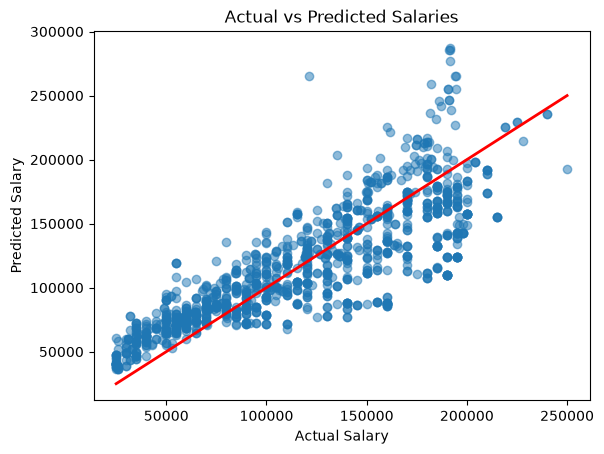

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Define Features (X) and Target (y)
X = df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']]
y = df['Salary']

# 2. Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate the Model
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean squared Error: ${mean_squared_error(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")

# 6. Show Coefficients (The impact of each feature)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coefficients)
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salaries')
plt.show()

In [57]:
import pickle
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [58]:
with open("linear_regression_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)